<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_10_5_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 6: Time Series in PyTorch**  

- Instructor: [Jeff Heaton](https://sites.wustl.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.wustl.edu/Programs/Pages/default.aspx)
- For more information visit the [class website](https://sites.wustl.edu/jeffheaton/t81-558/).

# Module 6 Material

* Part 6.1: Time Series Data Encoding for Deep Learning, PyTorch [[Video]]() [[Notebook]](t81_558_class_06_1_timeseries.ipynb)
* Part 6.2: LSTM-Based Time Series with PyTorch [[Video]]() [[Notebook]](t81_558_class_06_2_lstm.ipynb)
* Part 6.3: Transformer-Based Time Series with PyTorch [[Video]]() [[Notebook]](t81_558_class_06_3_transformer_timeseries.ipynb)
* Part 6.4: Predicting with Meta Prophet [[Video]]() [[Notebook]](t81_558_class_06_4_prophet.ipynb)
* **Part 6.5: Vibe Coding a Toy SP500 Model** [[Video]]() [[Notebook]](t81_558_class_06_5_sp500.ipynb)


# Google CoLab Instructions

The following code checks that Google CoLab is and sets up the correct hardware settings for PyTorch.


In [ ]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: using Google CoLab
Using device: cuda


# Part 6.5: Vibe Coding a Toy SP500 Model

We’ll wrap up this time series module by doing something a little different: instead of building the model step-by-step in a traditional, highly structured way, we’re going to “vibe code” a complete S&P 500 forecasting system. The goal here is not to produce a production-grade trading model, but to demonstrate how far you can push modern tools—especially PyTorch and data APIs—when you combine intuition, pattern recognition, and a bit of experimentation.

Financial time series are notoriously difficult to predict. Markets are influenced by an enormous number of interacting factors, many of which are unobservable, delayed, or inherently random. Even professional quantitative funds with massive datasets and compute resources struggle to consistently outperform simple benchmarks. That makes the S&P 500 a perfect example for this exercise: it is complex enough to be interesting, but familiar enough that we can reason about the results.

In this example, we’ll pull together multiple data sources, engineer a set of meaningful features, and train a recurrent neural network to predict next-day returns. From there, we’ll extend the model into a forward simulation that produces a full one-year forecast path, complete with volatility, drift, and mild mean reversion. This is where the “vibe coding” aspect really shows up—we’ll blend model outputs with statistical assumptions to create something that behaves more like a realistic market trajectory.

As always, a reminder: this example is for educational purposes only. It is not financial advice, and the predictions generated by this model should not be used for investment decisions. Past performance is not indicative of future results, and simple models like this are especially prone to overfitting, instability, and misleading outputs. The real value here is in understanding the pipeline, not trusting the forecast.


```text
Generate a single Google Colab-compatible Python code cell that builds a nontrivial PyTorch forecasting example for the S&P 500.

The code should:
- Install `yfinance` at the top using `!pip -q install yfinance`.
- Use these libraries: numpy, pandas, yfinance, torch, torch.nn, matplotlib.pyplot, and StandardScaler from scikit-learn.
- Set constants exactly as:
  - SEED = 42
  - LOOKBACK = 60
  - FORECAST_DAYS = 252
  - EPOCHS = 30
  - BATCH_SIZE = 64
  - LR = 1e-3
- Set NumPy and PyTorch random seeds.
- Use CUDA if available, otherwise CPU.
- Download adjusted close data from Yahoo Finance starting on 2000-01-01 for:
  - S&P 500: ^GSPC
  - NASDAQ: ^IXIC
  - VIX: ^VIX
  - 10-year Treasury yield: ^TNX
- Rename the columns to:
  - sp500
  - nasdaq
  - vix
  - tnx
- Drop missing rows.

Create a feature dataframe with:
- sp500_return as log return of sp500
- nasdaq_return as log return of nasdaq
- vix_return as log return of vix
- tnx_change as first difference of tnx
- sp500_mom_5 as 5-day momentum
- sp500_mom_20 as 20-day momentum
- sp500_vol_20 as 20-day rolling volatility of sp500_return
- sp500_ma_ratio_50 as price divided by 50-day moving average minus 1
- target as next-day sp500_return

Use this exact feature list:
[
    "sp500_return",
    "nasdaq_return",
    "vix",
    "vix_return",
    "tnx",
    "tnx_change",
    "sp500_mom_5",
    "sp500_mom_20",
    "sp500_vol_20",
    "sp500_ma_ratio_50",
]

Scale X and y separately with StandardScaler.

Create rolling sequences using LOOKBACK days of feature history to predict the next scaled target value. Split the sequences chronologically with 85% for training and 15% for testing. Convert arrays to PyTorch tensors directly on the selected device.

Define a PyTorch model named `LSTMReturnModel`:
- It should inherit from `nn.Module`.
- It should use a 2-layer LSTM.
- The LSTM should have hidden_size=64, batch_first=True, dropout=0.20.
- The final prediction head should be:
  - Linear(64, 32)
  - ReLU
  - Linear(32, 1)
- The forward pass should return the prediction from the last LSTM time step.

Train the model using:
- Adam optimizer
- learning rate LR
- MSELoss
- shuffled mini-batches with torch.randperm
- EPOCHS epochs
- BATCH_SIZE batch size
- Print average loss every 5 epochs.

After training:
- Evaluate on the test set.
- Inverse-transform the predictions and actual values.
- Print:
  - test residual daily standard deviation
  - mean predicted daily return
  - mean actual daily return

Then generate a 252-business-day forward forecast path:
- Start from the final LOOKBACK window.
- Start current_price from the latest sp500 value.
- Use the trained model recursively.
- Combine the model prediction with a long-term daily mean:
  - long_term_daily_mean = 0.00028
  - model_weight = 0.25
- Add random noise based on recent 60-day volatility:
  - vol_weight = 0.85
- Add a small mean-reversion term toward the latest 200-day moving average.
- Clip simulated daily log returns to [-0.025, 0.025].
- Update current_price using exp(simulated_return).
- Maintain and update feature values for the recursive forecast, including simulated sp500 return, approximate nasdaq return, estimated VIX, rolling volatility, momentum features, and stable tnx/tnx_change.
- Use scaler_x to transform the updated feature row before appending it to the rolling input window.

Create a pandas DataFrame named `forecast` with:
- forecast_sp500
- forecast_return
indexed by future business dates.

Print:
- latest S&P 500 value
- S&P 500 one year ago
- trailing 1-year return
- forecast 1-year value
- forecast 1-year return
- forecast high
- forecast low

Finally, plot:
- the trailing 252 trading days of historical S&P 500
- the forecast path
- a vertical dashed line at the forecast start
- title: "S&P 500: Trailing 1-Year History and 1-Year Stabilized PyTorch Forecast"
- x-label: Date
- y-label: S&P 500 Index Level
- legend
- light grid

Important constraints:
- Output only the complete Python code.
- Do not include markdown explanation.
- Keep everything in one large code block/cell.
- The code must run in Google Colab.
- The example is for education only and should not claim to produce reliable investment forecasts.
```

# Generated Code for SP500 Prediction

This example demonstrates how to build a multivariate time-series model in PyTorch to forecast the S&P 500 over the next year. It is important to emphasize that this exercise is educational in nature and is **not intended for investment use**.

Financial markets are notoriously difficult to predict. The S&P 500 reflects the aggregated expectations of millions of participants, incorporates vast amounts of public and private information, and reacts to unpredictable macroeconomic events, policy decisions, and geopolitical developments. In many ways, markets are close to being “efficient,” meaning that most readily available information is already priced in. As a result, even sophisticated models struggle to produce consistent, reliable forecasts.

Additionally, markets are **non-stationary**. The statistical properties of returns, volatility, and correlations change over time. A model trained on historical data is implicitly assuming that the future will behave similarly to the past, which is often not the case. Small biases in daily return predictions can compound significantly over time, and autoregressive forecasting can amplify errors as predictions are fed back into the model.

In this example, we intentionally simplify many aspects of the problem. We use a limited set of features, assume immediate availability of all inputs, and simulate future values for variables that are unknown at prediction time. These simplifications make the example tractable for a classroom setting, but they also introduce additional sources of error and uncertainty.

The forecast produced by this model should be viewed as a **plausible simulated path**, not a reliable prediction. The goal is to illustrate key concepts such as sequence modeling, feature engineering, scaling, and the challenges of forecasting noisy systems.

Finally, as is commonly stated in finance:

> **Past performance is not indicative of future results.**

Or more bluntly for this exercise:

> If this model appears to predict the market accurately, it is likely due to chance rather than skill.

Using device: cuda
Training sequences: 5,530
Testing sequences:  976
Epoch 05/30, loss=1.032853
Epoch 10/30, loss=1.022100
Epoch 15/30, loss=0.956891
Epoch 20/30, loss=0.849044
Epoch 25/30, loss=0.791933
Epoch 30/30, loss=0.740104
Test residual daily std: 0.01134
Mean predicted daily return: -0.00020
Mean actual daily return:    0.00061

Latest S&P 500 value:      7,209.01
S&P 500 one year ago:      5,569.06
Trailing 1-year return:    29.45%
Forecast 1-year value:     6,592.71
Forecast 1-year return:    -8.55%
Forecast high:             7,343.35
Forecast low:              6,391.75


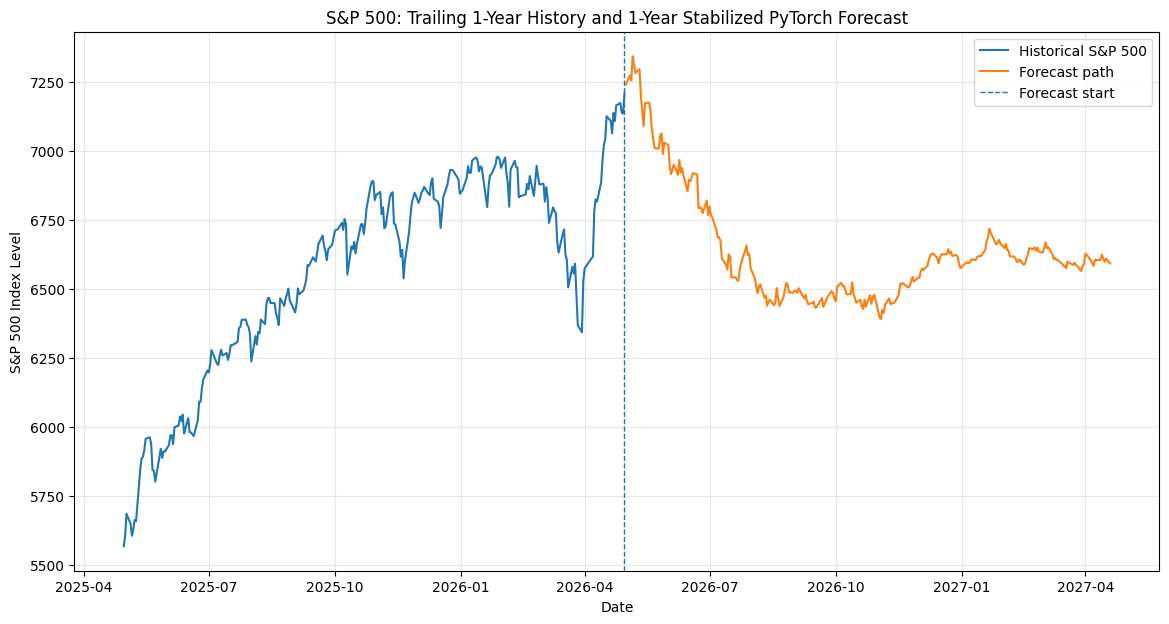

In [1]:
!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

SEED = 42
LOOKBACK = 60
FORECAST_DAYS = 252
EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tickers = {
    "sp500": "^GSPC",
    "nasdaq": "^IXIC",
    "vix": "^VIX",
    "tnx": "^TNX",
}

raw = yf.download(
    list(tickers.values()),
    start="2000-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

raw.columns = list(tickers.keys())
raw = raw.dropna()

df = raw.copy()

df["sp500_return"] = np.log(df["sp500"] / df["sp500"].shift(1))
df["nasdaq_return"] = np.log(df["nasdaq"] / df["nasdaq"].shift(1))
df["vix_return"] = np.log(df["vix"] / df["vix"].shift(1))
df["tnx_change"] = df["tnx"].diff()

df["sp500_mom_5"] = df["sp500"] / df["sp500"].shift(5) - 1
df["sp500_mom_20"] = df["sp500"] / df["sp500"].shift(20) - 1
df["sp500_vol_20"] = df["sp500_return"].rolling(20).std()
df["sp500_ma_ratio_50"] = df["sp500"] / df["sp500"].rolling(50).mean() - 1
df["target"] = df["sp500_return"].shift(-1)

df = df.dropna()

features = [
    "sp500_return",
    "nasdaq_return",
    "vix",
    "vix_return",
    "tnx",
    "tnx_change",
    "sp500_mom_5",
    "sp500_mom_20",
    "sp500_vol_20",
    "sp500_ma_ratio_50",
]

X_all = df[features].values
y_all = df["target"].values.reshape(-1, 1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X_all)
y_scaled = scaler_y.fit_transform(y_all)

X_seq = []
y_seq = []

for i in range(LOOKBACK, len(df)):
    X_seq.append(X_scaled[i - LOOKBACK:i])
    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)

split = int(len(X_seq) * 0.85)

X_train = torch.tensor(X_seq[:split], device=device)
y_train = torch.tensor(y_seq[:split], device=device)

X_test = torch.tensor(X_seq[split:], device=device)
y_test = torch.tensor(y_seq[split:], device=device)

print(f"Training sequences: {len(X_train):,}")
print(f"Testing sequences:  {len(X_test):,}")

class LSTMReturnModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.20,
        )
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        return self.fc(output[:, -1, :])


model = LSTMReturnModel(input_size=len(features)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(X_train.size(0), device=device)
    losses = []

    for i in range(0, X_train.size(0), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        xb = X_train[idx]
        yb = y_train[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:02d}/{EPOCHS}, loss={np.mean(losses):.6f}")

model.eval()

with torch.no_grad():
    test_pred_scaled = model(X_test).cpu().numpy()

test_pred = scaler_y.inverse_transform(test_pred_scaled).ravel()
test_actual = scaler_y.inverse_transform(y_test.cpu().numpy()).ravel()

residuals = test_actual - test_pred
residual_std = residuals.std()

print(f"Test residual daily std: {residual_std:.5f}")
print(f"Mean predicted daily return: {test_pred.mean():.5f}")
print(f"Mean actual daily return:    {test_actual.mean():.5f}")

last_window = X_scaled[-LOOKBACK:].copy()
current_price = df["sp500"].iloc[-1]

future_prices = []
future_returns = []

long_term_daily_mean = 0.00028
model_weight = 0.25
vol_weight = 0.85

recent_returns = list(df["sp500_return"].tail(60).values)
recent_vol = np.std(recent_returns)

recent_trend = df["sp500"].rolling(200).mean().iloc[-1]

for _ in range(FORECAST_DAYS):
    x_input = torch.tensor(
        last_window.reshape(1, LOOKBACK, len(features)),
        dtype=torch.float32,
        device=device,
    )

    with torch.no_grad():
        pred_scaled = model(x_input).cpu().numpy()

    predicted_return = scaler_y.inverse_transform(pred_scaled)[0, 0]

    expected_return = (
        model_weight * predicted_return
        + (1 - model_weight) * long_term_daily_mean
    )

    recent_vol = np.std(recent_returns[-60:])
    noise = np.random.normal(0, recent_vol * vol_weight)

    reversion = 0.000002 * (recent_trend - current_price) / recent_trend

    simulated_return = expected_return + noise + reversion
    simulated_return = np.clip(simulated_return, -0.025, 0.025)

    current_price = current_price * np.exp(simulated_return)

    future_returns.append(simulated_return)
    recent_returns.append(simulated_return)
    future_prices.append(current_price)

    raw_feature_values = scaler_x.inverse_transform(last_window[-1].reshape(1, -1))[0]
    feature_dict = dict(zip(features, raw_feature_values))

    feature_dict["sp500_return"] = simulated_return
    feature_dict["nasdaq_return"] = simulated_return + np.random.normal(0, recent_vol * 0.20)

    estimated_vix = max(10, min(45, recent_vol * np.sqrt(252) * 100))
    feature_dict["vix_return"] = np.log(estimated_vix / max(feature_dict["vix"], 1e-6))
    feature_dict["vix"] = estimated_vix

    feature_dict["sp500_vol_20"] = np.std(recent_returns[-20:])
    feature_dict["sp500_mom_5"] = np.sum(recent_returns[-5:])
    feature_dict["sp500_mom_20"] = np.sum(recent_returns[-20:])
    feature_dict["sp500_ma_ratio_50"] = (
        np.sum(recent_returns[-50:])
        if len(recent_returns) >= 50
        else np.sum(recent_returns)
    )

    feature_dict["tnx"] = feature_dict["tnx"]
    feature_dict["tnx_change"] = 0

    updated_features = np.array([feature_dict[col] for col in features]).reshape(1, -1)
    updated_scaled = scaler_x.transform(updated_features)[0]

    last_window = np.vstack([last_window[1:], updated_scaled])

last_date = df.index[-1]
future_dates = pd.bdate_range(last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

forecast = pd.DataFrame(
    {
        "forecast_sp500": future_prices,
        "forecast_return": future_returns,
    },
    index=future_dates,
)

today_value = df["sp500"].iloc[-1]
one_year_ago_value = df["sp500"].asof(df.index[-1] - pd.DateOffset(years=1))
yoy_return = today_value / one_year_ago_value - 1

forecast_end_value = forecast["forecast_sp500"].iloc[-1]
forecast_return_1y = forecast_end_value / today_value - 1

print()
print(f"Latest S&P 500 value:      {today_value:,.2f}")
print(f"S&P 500 one year ago:      {one_year_ago_value:,.2f}")
print(f"Trailing 1-year return:    {yoy_return:.2%}")
print(f"Forecast 1-year value:     {forecast_end_value:,.2f}")
print(f"Forecast 1-year return:    {forecast_return_1y:.2%}")
print(f"Forecast high:             {forecast['forecast_sp500'].max():,.2f}")
print(f"Forecast low:              {forecast['forecast_sp500'].min():,.2f}")

plot_history = df["sp500"].tail(252)

plt.figure(figsize=(14, 7))
plt.plot(plot_history.index, plot_history.values, label="Historical S&P 500")
plt.plot(forecast.index, forecast["forecast_sp500"], label="Forecast path")
plt.axvline(df.index[-1], linestyle="--", linewidth=1, label="Forecast start")

plt.title("S&P 500: Trailing 1-Year History and 1-Year Stabilized PyTorch Forecast")
plt.xlabel("Date")
plt.ylabel("S&P 500 Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()